Name Isabelle Maru Shapiro

Labpartner(s)

In [1]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np

# Class 6.1

Today we will start with fiunction sharing and do more matplotlib.

# Warmups 6.1

**W.1** Write a function that loops through a list of numbers and checks if they are odd or even, then returns a new list of "odd" or "even" for each element in the input list. For example:

Given the list [3,8,7] the function would return
["odd", "even", "odd"]

In [4]:
numbers = [1,2,3,4,5,6,7,8]
OddEven = []
for val in numbers:
    if val %2 == 0:
       OddEven.append("even")
    else:
        OddEven.append("odd")

print(OddEven)

['odd', 'even', 'odd', 'even', 'odd', 'even', 'odd', 'even']


# Lecture 6.1

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - first 4 people today, the rest on Wed

### Questions

### Loading and plotting netcdf files using xarray

Most modeling data output is in the form of netcdf files, as they can store more data (in binary) using less memory. Netcdf files are great because they tell you all about what is in the file (the variables and their units) with their metadata, which is kind of like the docstring we made for our function. There are a number of command line (unix-based) utilities for dealing with netcdf files, which I am not planning to cover in this course (though I use these all the time). Hit me up if you want some tutorials on this, or if enough of you are keen I will put some unix tutorials in the schedule.

Xarray is a python package that does analysis and basic plotting of netcdf files. This is actively being developed by folks like the pangeo consortium (https://pangeo.io), which is creating a number of python utilities for big data geoscience, like dealing with massive amounts of climate model output. There are other packages that can be used for parsing netcdf files, but they are cumbersome and clunky. Trust me, xarray is the best thing since sliced bread for big data geoscience. 

Let's grab some data and start playing with it. We are going to use the HYCOM Gulf of Mexico Analysis output, which is basically weather prediction for our local ocean made by the Navy, freely available. https://www.hycom.org.

In [2]:
import xarray as xr
# make sure you also have nectdf4 installed!

### Part 1: Load in the file (always the hardest part)!

We want the HYCOM GoM reanalysis product: https://www.hycom.org/dataserver/gom/gom-reanalysis
And we are going to use the coarser resolution (1/25 degree) version for computational speed, the "HYCOM-TSIS 1/25º Gulf of Mexico Reanalysis (GOMe0.04)" version, which goes from 2024-09-01 to present.

There are two ways to get this data, we can click around and download it, or we can use the opendap link (see http://xarray.pydata.org/en/stable/io.html).

In [12]:
# here I am going to grab the hindcast they made for Jan 1 2026. 

#First let's navigate to the website and download the 2d file.

# Note I can use the download the file I got by clicking on the https server link and putting the correct path to load in:
file_path= "039_archv.2026_001_00_2d.nc" # you will have to change this for your computer

# now upload from the file I downloaded manually:
hycom_data = xr.open_dataset(file_path, decode_times=False)

# honestly I don't know why you need the decode_times bit with open_dataset
# I just know it doesn't work most of the time if you leave it out (kudos for anyone who figures it out!)


In [13]:
hycom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:  CF-1.6
    title:        HYCOM
    source:       HYCOM archive file
    experiment:   01.4
    history:      archv2ncdf2d
    comment:      p-grid

The result is an xarray dataset, which is similar to the pandas dataframes you have been using. It has dimensions, coordinates and variables. The first thing to do when you get a dataset is to figure out what is in it and explore it a bit.

In [14]:
# what is the lat spacing and domain?

hycom_data.Latitude

# looks like it goes from 18.09 N to 31.96 N and the spacing is 0.04 degrees, i.e. 1/25, so that checks
# 1 degree is about 100 km, so thats 4 km model resolution

<xarray.DataArray 'Latitude' (Latitude: 385)> Size: 2kB
array([18.091648, 18.129667, 18.167677, ..., 31.892748, 31.926704, 31.960648],
      shape=(385,), dtype=float32)
Coordinates:
  * Latitude  (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y

In [15]:
hycom_data.Longitude

<xarray.DataArray 'Longitude' (Longitude: 525)> Size: 2kB
array([-98.      , -97.96002 , -97.91998 , ..., -77.119995, -77.08002 ,
       -77.03998 ], shape=(525,), dtype=float32)
Coordinates:
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X

In [16]:
hycom_data.ssh

<xarray.DataArray 'ssh' (MT: 1, Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.566e+04
    Date       (MT) float64 8B ...
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]

We will plot this in the next section

In [15]:
# alternatley, with a little help from ChatGPT I can make a nice workflow to get the file from the opendap (thredds) server
#https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc <-- link where we downloaded data from above 

#but also a threads cataloge on the website that you can download from 

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_01_2d.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data2 = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data2

# note, this would make a great function

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_01_2d.nc


<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

However, what I really want is to plot SST, so I need a file with temperature, let's check out the other file type

In [16]:
# modify the file to get the 3D output file

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_00_3z.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data_3D = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data_3D

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_3z.nc


<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.566e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf3z
    DODS_EXTRA.Unlimited_Dimension:  MT

In [17]:
#3d version had depth as well as SS values 

### Part2: Basic plotting with xarray (not publication ready!)

Note that one of the amazing things about xarray, is that it actually does not go and get the data until you call for it, so this will take a minute to upload.

In [18]:
hycom_data.ssh.plot()

AttributeError: 'Dataset' object has no attribute 'ssh'

Note that xarray, like pandas, uses matplotlib for plotting, and that it figured out to use the blue to red colormap based on the type of data. Pretty cool. 

Let's plot some temperature data and see how it compares. Since temperature data is given for the whole depth, we have to select a level.

water_temp
(MT, Depth, Latitude, Longitude)

In [20]:
hycom_data_3D.water_temp[0,0,:,:]  #[zeroith time, zeroith depth, entire long, entire lat]

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3240066 28.546928 ]
    _ChunkSizes:    [  1  14 193 263]

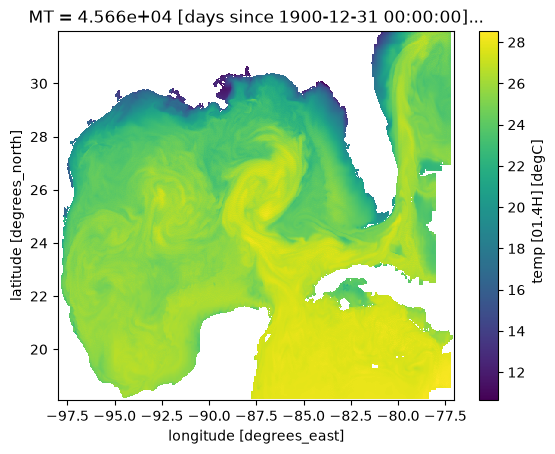

In [24]:
hycom_data_3D.water_temp[0,0,:,:].plot()

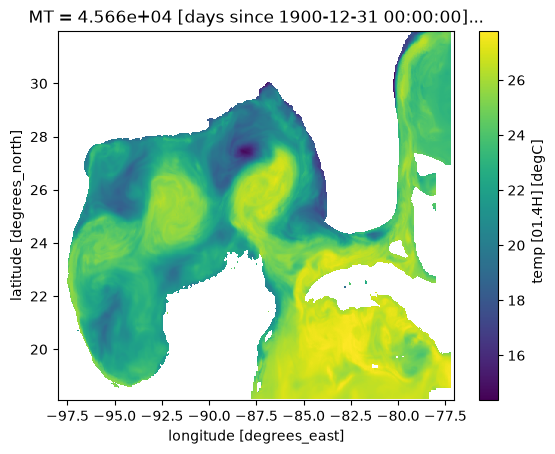

In [25]:
#compared to deeper in water column:
hycom_data_3D.water_temp[0,19,:,:].plot()

Those plots are really small. I like to change the default matplotlib preferences to make my plots bigger.

In [26]:
# change all the defaults (usually I stick this up with the import statements)

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [8.0, 5.0]
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['savefig.dpi'] = 500

mpl.rcParams['font.size'] = 12
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['figure.titlesize'] = 'medium'
mpl.rcParams['lines.linewidth']= 2.0

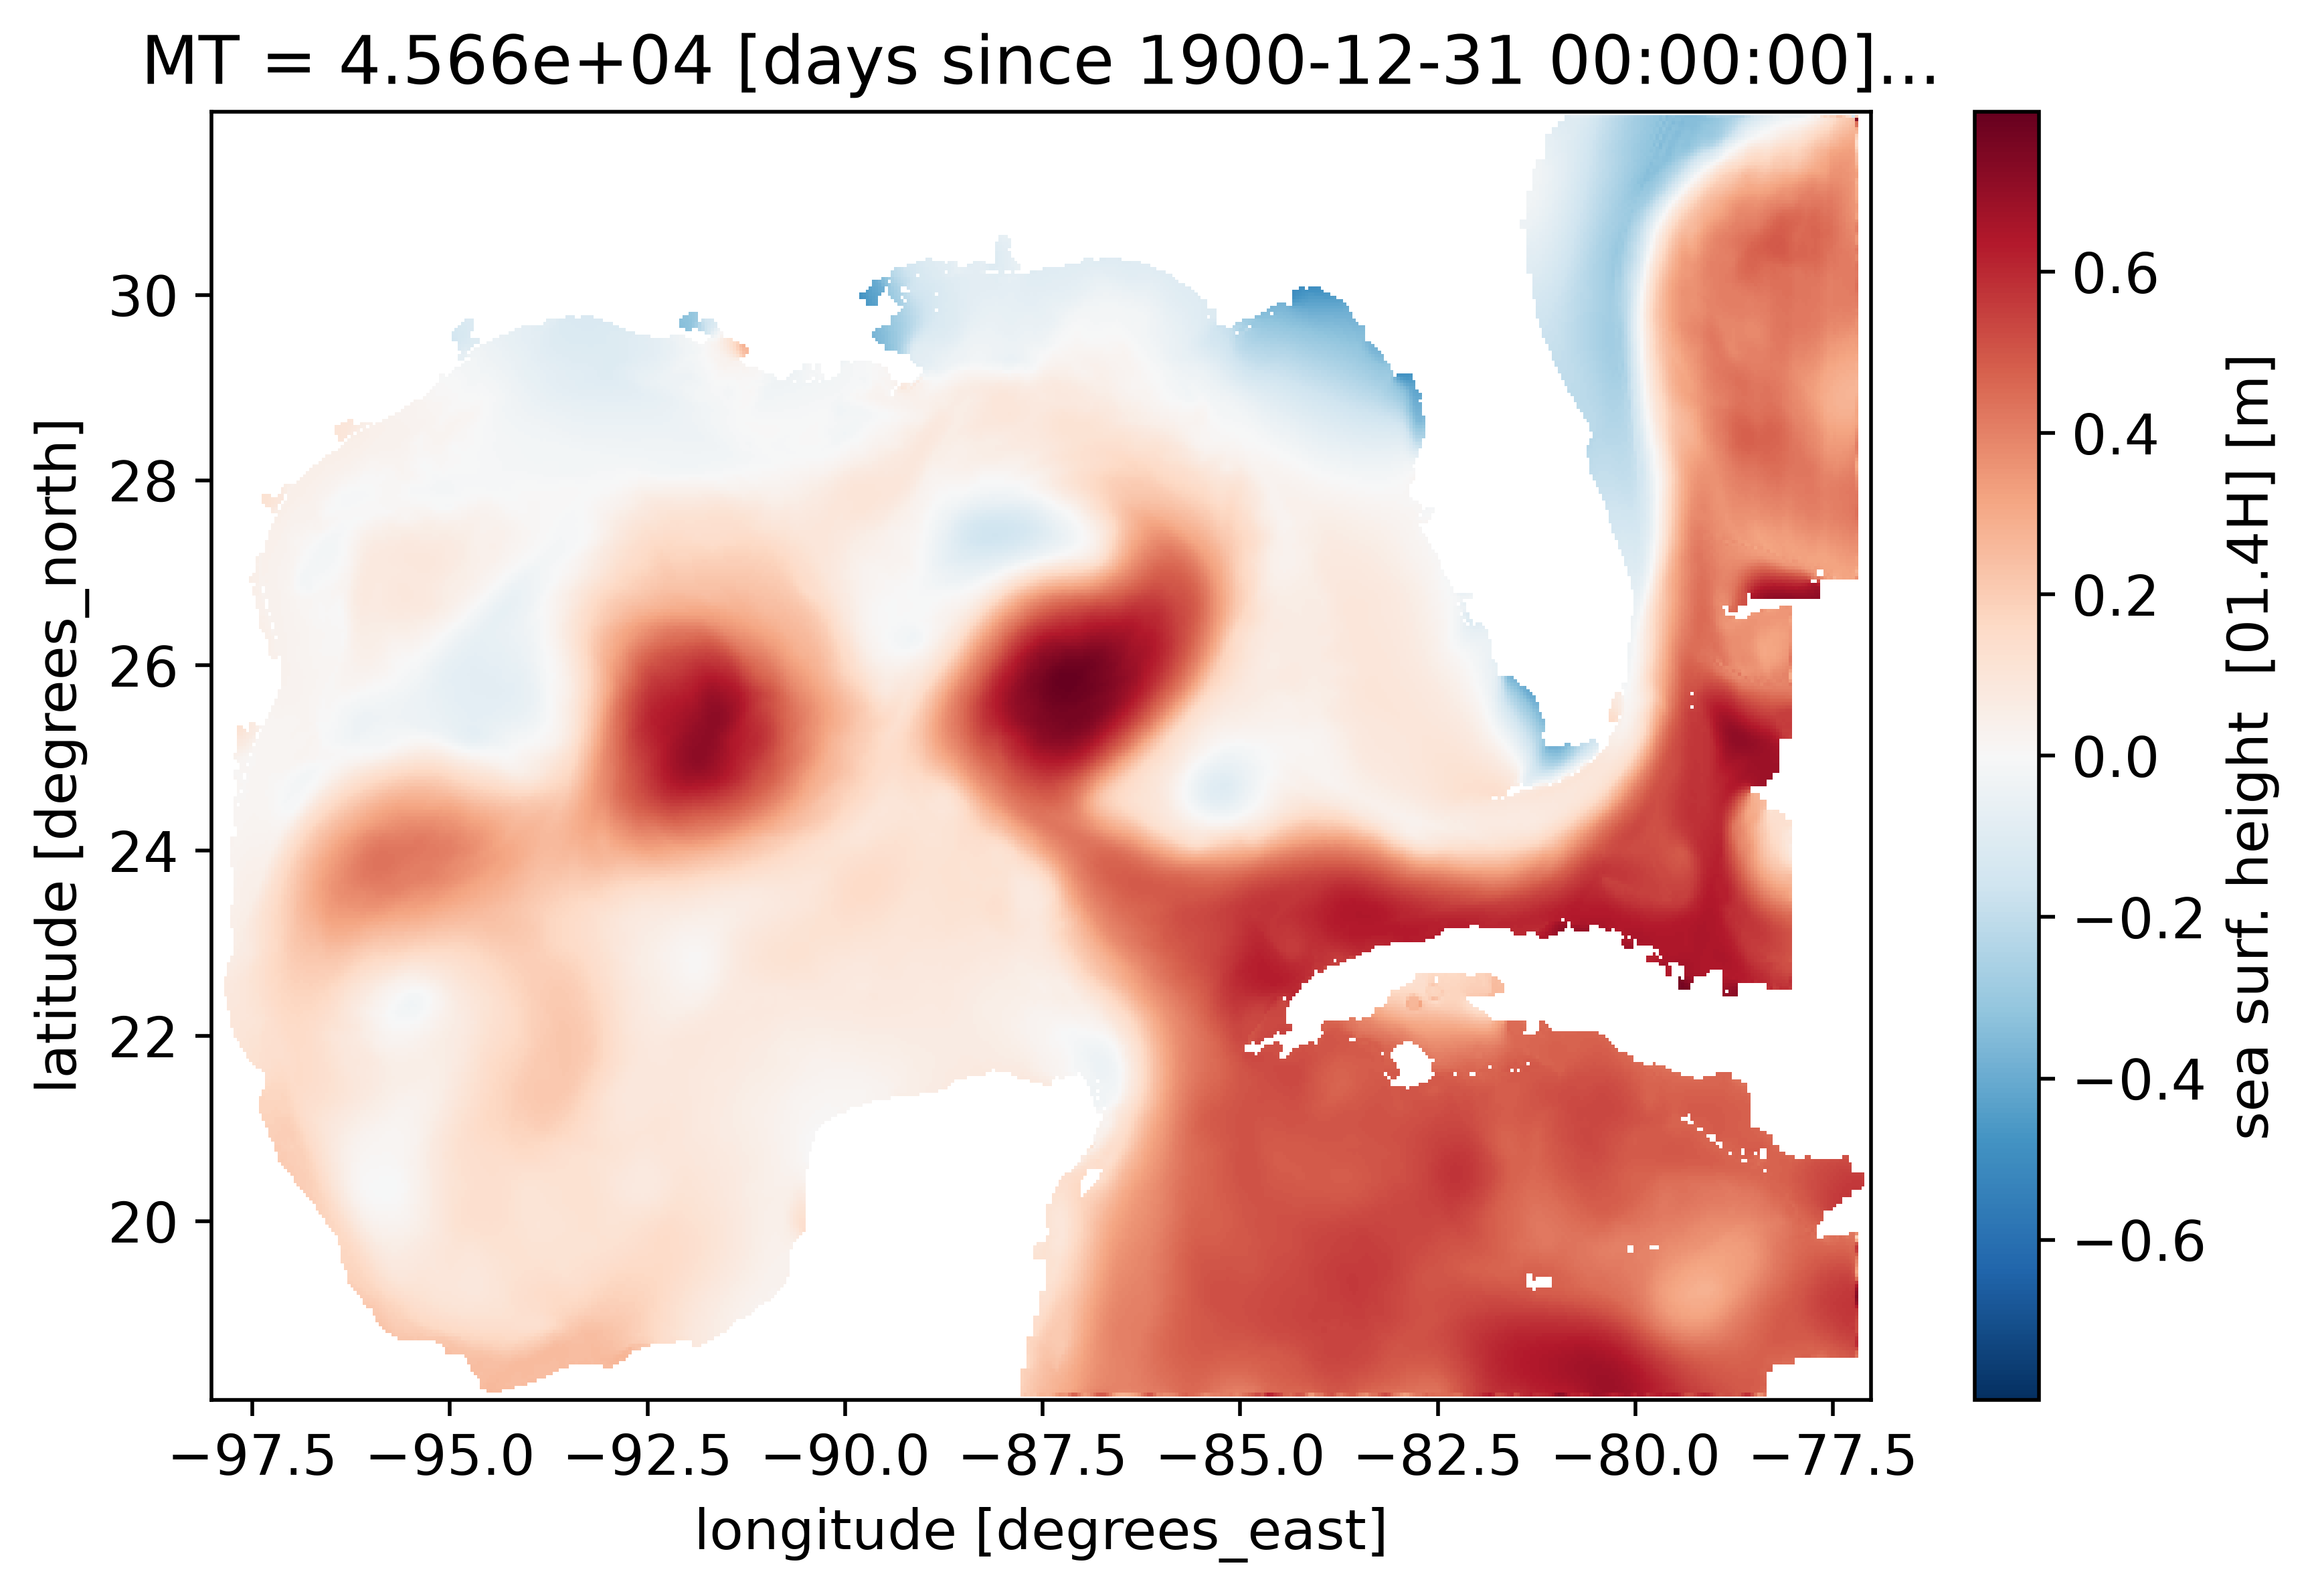

In [27]:
# now it's big and pretty.

hycom_data.ssh.plot()

Note if you know you are going to plot the same bit of data over and over again to fiddle with the plot, you can download the data you need and save it in an array to make the proccess faster.

In [28]:
#save sea surface temp as its own variable
SST = hycom_data_3D.water_temp[0,0,:,:]

In [29]:
type(SST)

xarray.core.dataarray.DataArray

In [30]:
SST # note it saves all the coordinates I need.

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3240066 28.546928 ]
    _ChunkSizes:    [  1  14 193 263]

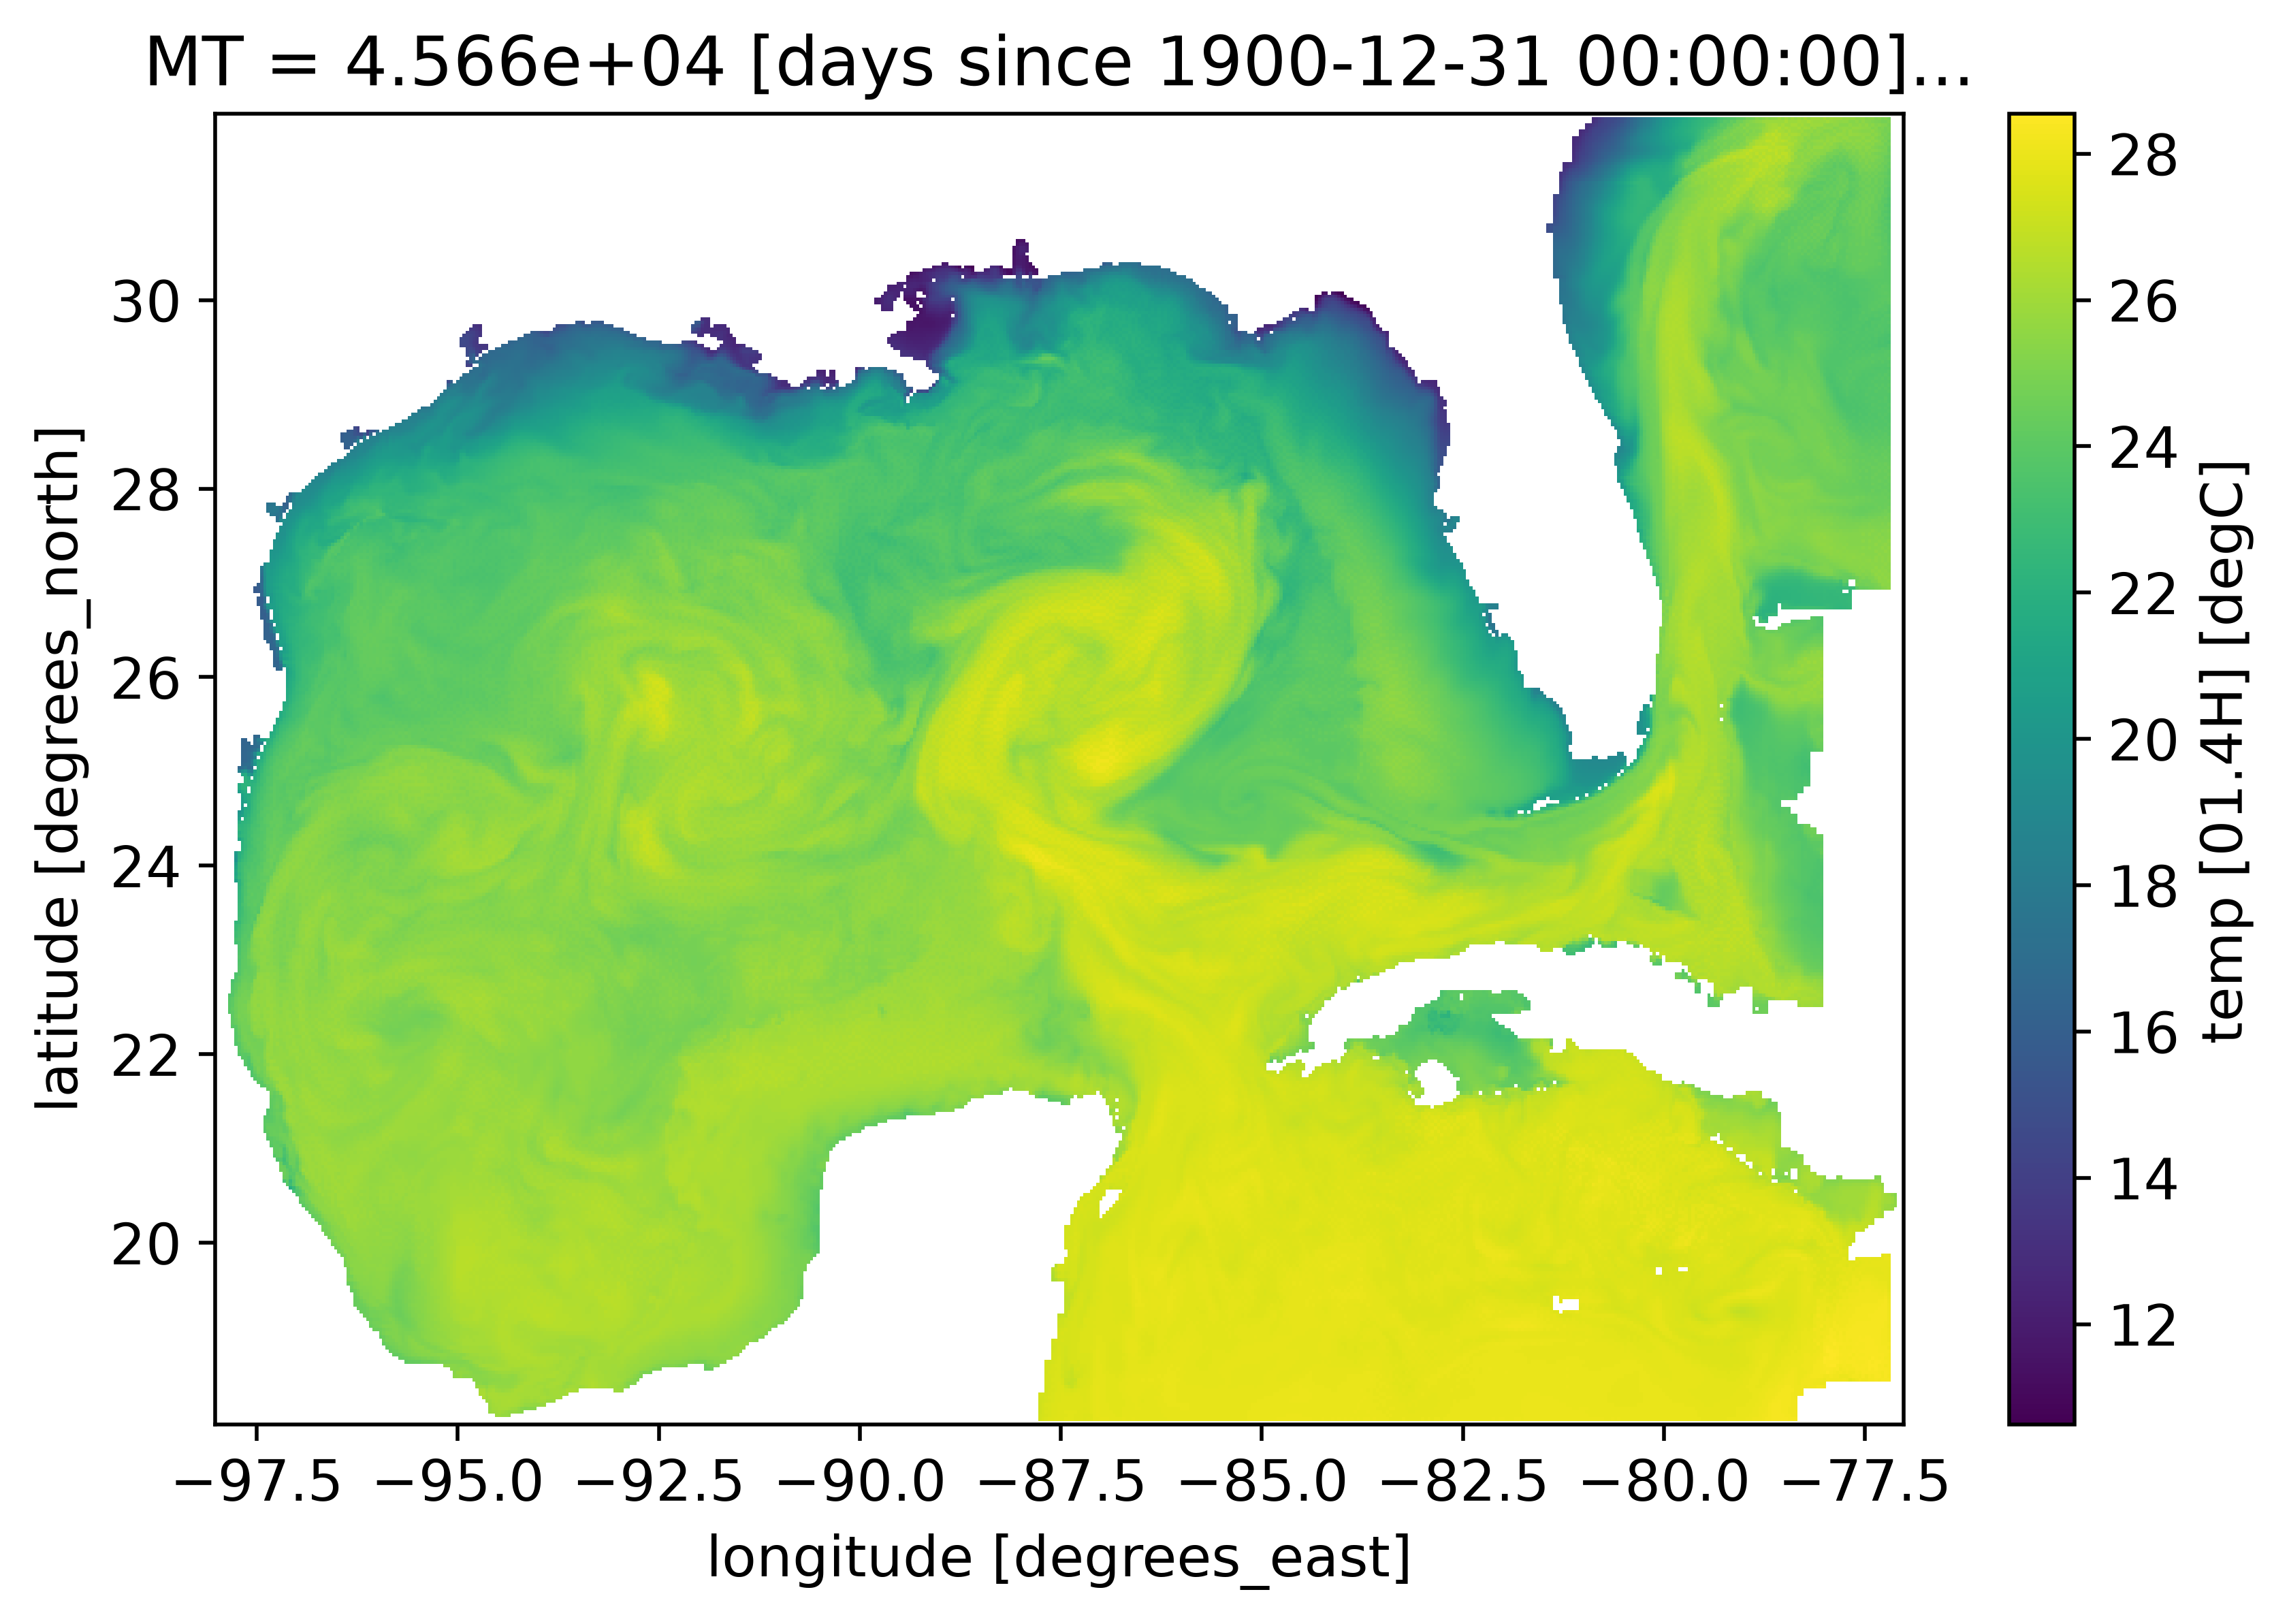

In [31]:
SST.plot()

I can also save this subset of the data to a new netcdf file locally very easily. See http://xarray.pydata.org/en/stable/io.html for more details.

In [32]:
#can then save this as it's own smaller file :
SST.to_netcdf('SST_2001_001_00.nc') # the new netcdf file is saved in the local directory

And then I load in the new netcdf file in the same way as I did the remote data, but using the local filepath

In [33]:
sst_data = xr.open_dataset('SST_2001_001_00.nc', decode_times=False)

In [34]:
sst_data

<xarray.Dataset> Size: 812kB
Dimensions:     (Latitude: 385, Longitude: 525)
Coordinates:
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT          float64 8B ...
    Date        float64 8B ...
    Depth       float32 4B ...
Data variables:
    water_temp  (Latitude, Longitude) float32 808kB ...

# Lab 6.1

**E.0** Finish Lab 5.2 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 1-2. Let me know if this feels like a good pace

Import matplotlib.pyplot as plt 
Fig, ax = plt.subplots()  ← makes a container to hold what you see on the page, and axis are the canvases 

ax.plot( x, y)
ax.plot(x1,y1) ←can add more than one set of data onto the same axis
Where data x is :  df[“column name”]


plt.show()

ax.plot(x, y, marker = “o”, linestyle=”--”, color = “r”)

		Linestyle = None
ax.set_xlabel (“label”)
ax.set_ylabel( “label”)
ax.set_title(“title”)


Small multiples: multiple small plots to show similar data across multiple subplots 

Fig, ax = plt.subplots(3,2) ← three rows and two columns of subplots 


Ax[0,0].plot ←plot on the first axis 
If you have plt.subplots(2,1) you only have one column: for ax you would do : ax[0] and ax[1], with no coordinates

Fig, ax = plt.subplots(3,2, sharey = True) ←makes both subplots have the same y axis values

Data time stored as an index:

Data = pd.read_csv(“data”, parse_dates = [“date column name”], index_col = [“date colum name”]
ax.plot(data.index, y[‘column’]

Slicing into data frame:

Slice = data[“date time” : “date time”]



Two lines on one plot:
Ax2 = ax.twinx() ←two axis share the same x axis but the ys are different 
ax2 .plot(data2, data2)

ax.tick_params(‘either y or x’, colors= ‘blue’)

Annotations

ax.annotate(“annotation”, xy = (pd.Timestamp (“date”), value at that date), xytext = (pd.Timestample(‘location’), y value), arrowprops = {“arrowstyle’”:”->”, “color”:”grey”})


**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

See also http://xarray.pydata.org/en/stable/plotting.html for more info about plotting right from xarray (optional).

**E.3** Using the lecture as a guide, save the sea surface temperature at ~100 m depth on your birthday in 2025 as a new, local netcdf file. You don't have to submit the file, just the code here.

In [21]:
data = xr.open_dataset("039_archv.2025_051_00_3z.nc", decode_times=False)

In [27]:
data.water_temp[0,0,:,:]

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.534e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3999064 28.501812 ]
    long_name:        temp [01.4H]

In [31]:
data.Depth

<xarray.DataArray 'Depth' (Depth: 40)> Size: 160B
array([0.00e+00, 2.00e+00, 4.00e+00, 6.00e+00, 8.00e+00, 1.00e+01, 1.20e+01,
       1.50e+01, 2.00e+01, 2.50e+01, 3.00e+01, 3.50e+01, 4.00e+01, 4.50e+01,
       5.00e+01, 6.00e+01, 7.00e+01, 8.00e+01, 9.00e+01, 1.00e+02, 1.25e+02,
       1.50e+02, 2.00e+02, 2.50e+02, 3.00e+02, 3.50e+02, 4.00e+02, 5.00e+02,
       6.00e+02, 7.00e+02, 8.00e+02, 9.00e+02, 1.00e+03, 1.25e+03, 1.50e+03,
       2.00e+03, 2.50e+03, 3.00e+03, 4.00e+03, 5.00e+03], dtype=float32)
Coordinates:
  * Depth    (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 2.5e+03 3e+03 4e+03 5e+03
Attributes:
    standard_name:  depth
    units:          m
    positive:       down
    axis:           Z

In [35]:
data.Depth[20]

<xarray.DataArray 'Depth' ()> Size: 4B
array(125., dtype=float32)
Coordinates:
    Depth    float32 4B 125.0
Attributes:
    standard_name:  depth
    units:          m
    positive:       down
    axis:           Z

**E.4** Plot the above (your 2025 birthday SST) using the basic xarray funcitons

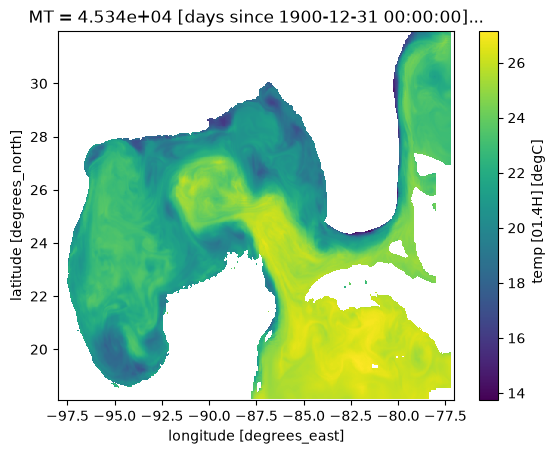

In [32]:
data.water_temp[0,19,:,:].plot()

In [37]:
SST2025 = data.water_temp[0,19,:,:]
SST2025.to_netcdf('SST_2025_051_00_3z.nc') # the new netcdf file is saved in the local directory

**E.5** What is the SST for Flower Garden Banks national marine sanctuary on your birthday? Show your work

In [38]:
#Flower Garden Banks national marine sanctuary is three different areas in gulf 
#boundary for all three is -94.308884 --> -93.570924, 28.169501--> 27.819762 according to Noaa shapefile https://flowergarden.noaa.gov/visiting/buoyboundary.html



In [71]:
#SSTFG is surf temp for all of gulf:
SSTFG =  data.water_temp[0,0,:,:]

#have to pull out only 28.16 to 27.81 from latitude of SSTFG
Subset = SSTFG.sel(Latitude=slice(27.819762,28.169501))
Subset = Subset.sel(Longitude=slice(-94.308884,-93.570924))

In [84]:
x = Subset.mean()

print(x)

#average sea surface temp in Flower Garden in 21.72291 C

<xarray.DataArray 'water_temp' ()> Size: 4B
array(21.72291, dtype=float32)
Coordinates:
    MT       float64 8B 4.534e+04
    Date     float64 8B ...
    Depth    float32 4B 0.0
Attributes:
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3999064 28.501812 ]
    long_name:        temp [01.4H]


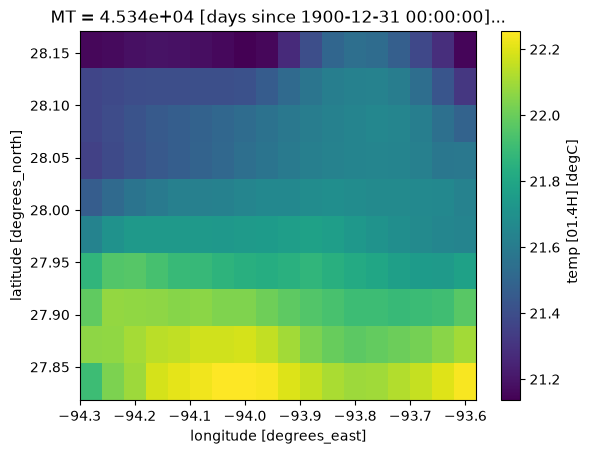

In [85]:
Subset.plot()